In [1]:
# imports
import pandas as pd
from csv import reader
from itertools import permutations
from itertools import combinations
import ipyplot

### Filtering User Input:

The first thing done with user input is to filter it. Commas and other punctuation are taken out so we are left with a string of just the words

In [2]:
# We should add some filtering to the clue words so that commas and other punctuation does not impact our program
def filterSentence(sentence):
    """input is a user defined sentence, this is filtered 
    by taking out all punctuation leaving just characters"""
    filterWords = [",", ".", "!", "?"]

    for word in filterWords:
        sentence = sentence.replace(word, "")

    return sentence


### Database Loading

We loaded in a database hosted on github and linked from a reference code project linked below.

link: https://ramnarasimhan.medium.com/using-python-to-find-song-titles-43b175284c46
        
This database contains the top 100 songs for each year from 1964 to 2015. This database is ideal because it uses popular songs that the user is more likely to know. Selectively choosing our database allows us to cut down on computing time.

The songs were loaded into a list with their titles and another containing artist name for easier reference. These lists were organized into a dictionary with the key being the song title.

In [3]:
# This is a initial list of songs, just the top 100 songs from each year from 1964
# We are using pandas to grab the CSV data into a form that we can work with
songs_url = 'https://raw.githubusercontent.com/walkerkq/musiclyrics/master/billboard_lyrics_1964-2015.csv'
songs = pd.read_csv(songs_url, encoding="ISO-8859-1")


In [4]:
# We also keep track of the artist name in case we want to use it later for our output
# Creating two lists to hold the songs and the artist of that same song
songList = []
artistList = []
for song in songs['Song']:
    songList.append(song)

for artist in songs["Artist"]:
    artistList.append(artist)


In [5]:
songDict = {}
# We are making a dictionary of the songs so the search time is faster. Hash tables are faster to search through than lists
# We could use the lists too, but if we want to incorperate the artist name in anyway we can easily access the info with the dictionary
for i in range(len(songList)):
    songDict[songList[i]] = artistList[i]


### Parsing Functions

The functions below help parse through the song dictionary with one returning whether or not a song is actually in the list and the other returning the index of a song in the dictionary.

In [6]:
# Just a simple funciton that returns True or False weather or not the song is in our song list
def inDict(sentence):
    if sentence in songDict:
        return True
    else:
        return False


In [7]:
def getIndexWord(sentenceList, sentence):

    word = sentence.split()[-1]

    return sentenceList.index(word)


### Greedy Matching

The function below is self-contained so the input is taken in then filtered. Then the full sentence is checked for a possible song title match in a greedy approach, taking off the first word if no match is found. This approach worked in some cases, but misses some song titles embedded into the middle of sentence.

In [47]:
# This method will look for all the possible matches greedy but on large inputs it will not run fast enough 
# For longer sentence inputs, we are going to do another matching of sentences 
def songSentence(sentence):
    sentence = filterSentence(sentence)
    res = []
    
    #splitting words in sentence into a list
    sentenceList = sentence.split()

    start = 0
    end = len(sentenceList)
    track = 0 

    if len(sentenceList) == 1: 
        if inDict(sentenceList[0]): 
            res.append(sentenceList[0])
            return res 
        else: 
            print("No songs found")
            return []

    b = True
    while b:
        if len(sentenceList[start:end]) == 1 and track != len(sentenceList): 
            start = track + 1 
            end = len(sentenceList)
            track += 1 
        
        tempSentence = " ".join(sentenceList[start:end])
        # print(tempSentence)

        if inDict(tempSentence):
            res.append(tempSentence)
            start = end
            end = len(sentenceList)
            index = getIndexWord(sentenceList, res[-1]) + 1 
            if index < end: 
                start = index 
                track = index
        else:
            end -= 1

        if start == end: 
            b = False 

    return res


In [9]:
d = songSentence("i like it when you buy me this diamond ring")
d


['i like it', 'this diamond ring']

In [10]:
songList

['wooly bully',
 'i cant help myself sugar pie honey bunch',
 'i cant get no satisfaction',
 'you were on my mind',
 'youve lost that lovin feelin',
 'downtown',
 'help',
 'cant you hear my heart beat',
 'crying in the chapel',
 'my girl',
 'help me rhonda',
 'king of the road',
 'the birds and the bees',
 'hold me thrill me kiss me',
 'shotgun',
 'i got you babe',
 'this diamond ring',
 'the in crowd',
 'mrs brown youve got a lovely daughter',
 'stop in the name of love',
 'unchained melody',
 'silhouettes',
 'ill never find another you',
 'cara mia',
 'mr tambourine man',
 'cast your fate to the wind',
 'yes im ready',
 'whats new pussycat',
 'eve of destruction',
 'hang on sloopy',
 'ticket to ride',
 'red roses for a blue lady',
 'papas got a brand new bag',
 'game of love',
 'the name game',
 'i know a place',
 'back in my arms again',
 'baby im yours',
 'the jolly green giant',
 'hush hush sweet charlotte',
 'like a rolling stone',
 'im telling you now',
 'ferry cross the mersey'

### A new method

This new method is an improvement on the previous greedy message. It takes each word in the inputted sentence and considers whether it could be the start of a song title, by iterating through the database. Each match found is recorded so that at the end only the best matching song titles are outputted. Right now, the best song titles are those that are the longest, but they could also be organized by how popular they are or other heuristics to cater to the user.

In [60]:
# This is an even greedier method for matching the songs
# for large inputs, we should use this funciton
# The way it works is that we only look for matches that are a given range of words long 
# Once we match, we say that it is the best match and move on thinking that it is the best match 
# Then once we have a list of lists of songs, we can filter by the length and choose the list that has the most matches or vice versa 
def songSentenceImprove2(sentence):

    sentence = filterSentence(sentence)
    res = []
    sentenceList = sentence.split()

    if len(sentenceList) == 1:
        if inDict(sentenceList[0]):
            res.append(sentenceList[0])
            return res
        else:
            print("No songs found")
            return []

    stepLower = 2
    stepHigher = 7

    for step in range(stepLower, stepHigher): 
        start = 0
        end = len(sentenceList)
        tempRes = []
        b = True
        e = end 
        while b:
            if start+step > len(sentenceList): 
                tempSentence = " ".join(sentenceList[start:end])
                e = end 
                if inDict(tempSentence):
                    tempRes.append(tempSentence)
                    res.append(tempRes)
                    b = False 
            else: 
                tempSentence = " ".join(sentenceList[start:start+step])
                e = start + step
            # print(tempSentence)
            if b: 
                if inDict(tempSentence):
                    tempRes.append(tempSentence)
                    start = e
                    if start >= len(sentenceList):
                        res.append(tempRes)
                        b = False
                else:
                    start += 1

    # print(res)
    return res 



### Testing the function
The cells below show various tests of the previous function. Many of these inputs contain deliberate placement of song titles to ensure that matches are able to occur.

In [12]:
var = songSentenceImprove2("wooly bully how are you doing. I want you to hold me thrill me kiss me, because ill never find another you")
var

[['wooly bully', 'hold me', 'kiss me', 'you'],
 ['you'],
 ['you'],
 ['ill never find another you'],
 ['hold me thrill me kiss me', 'ill never find another you']]

In [13]:
sList = ["i", "like", "it"]
sentence = "i like it"

y = getIndexWord(sList, sentence)
y

2

In [14]:
d = songSentence("i like it when you buy me this diamond ring do you know that")
d


['i like it', 'this diamond ring']

In [15]:
# From this example, we can see that the function can seperate the sentence into the two songs that are present in the sentence
t = songSentence(
    "mrs brown youve got a lovely daughter, ill never find another you")
t


['mrs brown youve got a lovely daughter', 'ill never find another you']

### Consolidating the program into a function

The function runSong below consolidates the previous work into one function that makes using the program easier. This will facilitate potential for future work in making this program in a website format to make it easier to interact with users.

In [34]:
# The main funciton that we will be calling to get the song names
# we chose to return the list with the most songs for our improved song filtering 
# we can also choose to return the one with the min or anything like that 
def runSong(sentence): 

    sentenceList = sentence.split()
    if len(sentenceList) > 8: 
       listOSongs = songSentenceImprove2(sentence)
       longestList = max(listOSongs,key=len)
       return longestList
    else: 
        return songSentence(sentence)

### Testing the song finding capabilities with our two funcitons 

In [17]:
s = runSong("you were on my mind unchained melody")
s


['you were on my mind', 'unchained melody']

In [18]:

o = runSong("wooly bully how are you doing. I want you to hold me thrill me kiss me, because ill never find another you")
o


['wooly bully', 'hold me', 'kiss me', 'you']

In [19]:
n = runSong("i like it when you buy me this diamond ring silhouettes")
n


['i like it', 'this diamond ring', 'silhouettes']

In [20]:
g = runSong("mr tambourine man ill never find another you")
g


['mr tambourine man', 'ill never find another you']

### Now that we can get the songs, we need a way to link the videos, this part will go to youtube and return urls of the songs that we found 

Doing this is the first step to making the visual portion of the output. By having album covers and song video links, it actually connects the user with the song versus simply reporting back song titles. To do this, we use a library called youtubesearchpython. This library allows us to search youtube and we get a result back that contains information about the video. From the result, we can extract both the url of the videos and thumbnail images for the videos. 

In [21]:
# Imports 
from youtubesearchpython import VideosSearch


In [22]:
# Practice to show how the results are given back from the library 
videosSearch = VideosSearch(song, limit=1)
print(videosSearch.result())

{'result': [{'type': 'video', 'id': 'EgqUJOudrcM', 'title': 'Calvin Harris & Disciples - How Deep Is Your Love', 'publishedTime': '6 years ago', 'duration': '4:21', 'viewCount': {'text': '1,496,104,078 views', 'short': '1.4B views'}, 'thumbnails': [{'url': 'https://i.ytimg.com/vi/EgqUJOudrcM/hq720.jpg?sqp=-oaymwEcCOgCEMoBSFXyq4qpAw4IARUAAIhCGAFwAcABBg==&rs=AOn4CLCM2xhx4v-wAr7P3kq3b-362diMrQ', 'width': 360, 'height': 202}, {'url': 'https://i.ytimg.com/vi/EgqUJOudrcM/hq720.jpg?sqp=-oaymwEcCNAFEJQDSFXyq4qpAw4IARUAAIhCGAFwAcABBg==&rs=AOn4CLBjq0LckpqUaPeq2iVaS3aRWDhrZg', 'width': 720, 'height': 404}], 'richThumbnail': {'url': 'https://i.ytimg.com/an_webp/EgqUJOudrcM/mqdefault_6s.webp?du=3000&sqp=CION1pMG&rs=AOn4CLBazQW9VKIBhEauEL-3zoyOqb3vyw', 'width': 320, 'height': 180}, 'descriptionSnippet': [{'text': 'I want you to breathe me in Let me be your air Let me roam your body freely No inhibition, no fear '}, {'text': 'How deep is your love', 'bold': True}, {'text': '? Is it like\xa0...'}], 'c

In [23]:
# Testing the function to extract the urls given a list of songs 
# Important to note that we are returning the first result from the youtube search 
listSongs = ['i like it', 'this diamond ring', 'silhouettes']
# listSongs = ["i like it"]
urlLinks = []
for song in listSongs: 
    videosSearch = VideosSearch(song, limit=1)
    link = videosSearch.result()["result"][0]["link"]
    urlLinks.append(link)

print(urlLinks)


['https://www.youtube.com/watch?v=xTlNMmZKwpA', 'https://www.youtube.com/watch?v=bKTOizdhan8', 'https://www.youtube.com/watch?v=p_WUSNV6ACE']


### Getting the URL links 

Consolidating the above code into a function that we can call for our final function

In [41]:
def getUrlLinks(listSongs): 
    urlLinks = []

    if len(listSongs) == 0: 
        return []

    for song in listSongs:
        videosSearch = VideosSearch(song, limit=1)
        link = videosSearch.result()["result"][0]["link"]
        urlLinks.append(link)
    
    return urlLinks


### Getting Images

We also want to display the thumbnail images of the videos that we searched for. Using the same structure as the code above, we can extract the url of the thumbnail images for each of the videos that we found. 

In [25]:
def getSongThumbnail(listSongs):
    thumbnails = []

    if len(listSongs) == 0:
        return []

    for song in listSongs:
        videosSearch = VideosSearch(song, limit=1)
        link = videosSearch.result()["result"][0]["thumbnails"][0]["url"]
        thumbnails.append(link)

    return thumbnails


In [26]:
# testing to see if the url of the thumbnail images are returned 
listSongs = ['i like it', 'this diamond ring', 'silhouettes']

thumbnails = getSongThumbnail(listSongs)
thumbnails

['https://i.ytimg.com/vi/xTlNMmZKwpA/hqdefault.jpg?sqp=-oaymwEcCOADEI4CSFXyq4qpAw4IARUAAIhCGAFwAcABBg==&rs=AOn4CLBMyKLeZvTxSi89EBrCg5cUEnNe0w',
 'https://i.ytimg.com/vi/bKTOizdhan8/hq720.jpg?sqp=-oaymwEcCOgCEMoBSFXyq4qpAw4IARUAAIhCGAFwAcABBg==&rs=AOn4CLCx22yOQ6l-NE3mF10wAeKyfcwPMA',
 'https://i.ytimg.com/vi/p_WUSNV6ACE/hqdefault.jpg?sqp=-oaymwEcCOADEI4CSFXyq4qpAw4IARUAAIhCGAFwAcABBg==&rs=AOn4CLBATfPQP_Xr2DeTIdW3l4Umx8BbFg']

### Displaying the images 

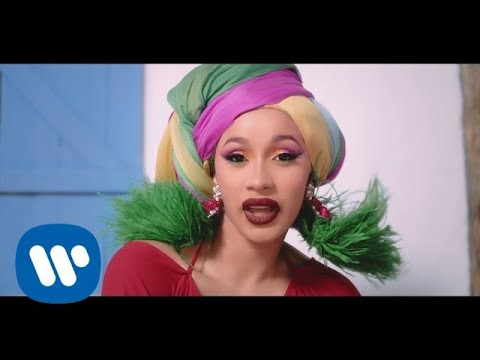

In [27]:

from IPython import display
display.Image('https://i.ytimg.com/vi/xTlNMmZKwpA/hqdefault.jpg?sqp=-oaymwEcCOADEI4CSFXyq4qpAw4IARUAAIhCGAFwAcABBg==&rs=AOn4CLBMyKLeZvTxSi89EBrCg5cUEnNe0w.jpg')


### Consolidating the above functionalities into one function 

With this we can give in a sentence and we will get the images associated with the songs in the sentence and also the URL links to the youtube videos 

In [50]:
# Final fucntion that can take a sentence and return urls to videos and thumbnail images 
def songafy(sentence): 
    listSongs = runSong(sentence)
    urlLinks = getUrlLinks(listSongs)
    thumbnails = getSongThumbnail(listSongs)
    
    if thumbnails == []: 
        return 

    for i in range(len(thumbnails)):
        thumbnails[i] = thumbnails[i] + ".jpg" 
    for song in listSongs:
        print(song)
    ipyplot.plot_images(thumbnails, max_images=20, img_width=150)

    for url in urlLinks: 
        print(url)

    return 

In [29]:
testSentence = "i like it when you buy me this diamond ring silhouettes"
songafy(testSentence)


i like it
this diamond ring
silhouettes


https://www.youtube.com/watch?v=xTlNMmZKwpA
https://www.youtube.com/watch?v=bKTOizdhan8
https://www.youtube.com/watch?v=p_WUSNV6ACE


### Testing the Functionality with different sentences 

In [30]:
testSentence = "I love being together. Dancing under the moonlight in the stars is beautiful. "
songafy(testSentence)


beautiful


https://www.youtube.com/watch?v=eAfyFTzZDMM


In [36]:
testSentence = "its not unusual to love stacys mom"
songafy(testSentence)


its not unusual


https://www.youtube.com/watch?v=k-HdGnzYdFQ


In [54]:
testSentence = "secret agent man the sound of silence is just like me"
songafy(testSentence)


secret agent man
just like me


https://www.youtube.com/watch?v=6iaR3WO71j4
https://www.youtube.com/watch?v=ub3XhDi6cV4


In [61]:
testSentence = "i fought the law in a yellow submarine with zorba the greek and died hungry"
songafy(testSentence)

yellow submarine
hungry


https://www.youtube.com/watch?v=m2uTFF_3MaA
https://www.youtube.com/watch?v=75NQK-Sm1YY
